# Causal Discovery and Causal Feature Selection for Robust Prediction

This tutorial walks through the key ideas and algorithms at the intersection of causal inference and robust machine learning.
The tutorial is structured as follows:

1. **Pairwise causal discovery** — can we tell which variable causes which, from observational data alone?
2. **Multivariate causal discovery** — recovering the full causal graph over many variables
3. **Multivariate causal feature selection** — finding the Markov Blanket of a target variable
4. **CFS for robust prediction** — why causal parents are more stable predictors than correlated features
5. **Invariant Causal Predictors** — a principled method to find invariant features across environments

In [1]:
# Standard library
import time

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy / stats
from scipy.stats import pearsonr
from numpy.linalg import lstsq
import dcor

# Scikit-learn
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Data utilities
from cdt.data import load_dataset

# Custom modules / Causal discovery
from src.causal_discovery import ges, adjacency, pc_alg, fci_alg, lingam
from src.causal_feature_selection import (
    hiton_mb, iamb, mmpc, mb_ges, resit_mb, hiton_pc
)
from invariant_causal_prediction import icp
from src.kci import kci_test

# Local project modules
# Note: Replaced * with specific imports or module reference for clarity
from src import generate_scm
from src import MB

from src.generate_scm import *


# Reproducibility
np.random.seed(2)

No GPU automatically detected. Setting SETTINGS.GPU to 0, and SETTINGS.NJOBS to cpu_count.


---
## Section 1 — Pairwise Causal Discovery

### 1.1 The problem

You have two variables X and Y. You observe them jointly. The question is: does X cause Y, or does Y cause X?

This may sound like philosophy, but it has a clean statistical formulation. The key insight comes from **Structural Causal Models (SCMs)**. If X → Y, then:

$$Y = f(X) + \varepsilon_Y, \quad \varepsilon_Y \perp X$$

where f is some function and ε is independent noise. In the *wrong* direction (Y → X), you would need:

$$X = g(Y) + \varepsilon_X, \quad \varepsilon_X \perp Y$$

But this consistency — noise independent of the cause — cannot hold in *both* directions simultaneously (except in degenerate cases like linear Gaussian). This asymmetry is what lets us identify the causal direction.

### 1.2 RESIT — Regression with Subsequent Independence Test

The algorithm is simple:
1. Fit X → Y, compute residuals R_{XY} = Y - f̂(X)
2. Test whether X ⊥ R_{XY}
3. Repeat in the other direction Y → X, get R_{YX}
4. The direction where cause ⊥ residuals is the causal one

The independence test used here is KCI (Kernel-based Conditional Independence), a non-parametric test that can detect arbitrary dependencies.


### 1.3 Synthetic example — linear SCM with uniform noise

We generate a simple SCM: X → Y, where Y = aX + ε, ε ~ Uniform. We use a linear regression model for the fit and KCI for the independence test.

Run the cell below and inspect the residual plots. The key observation: residuals in the correct direction (X → Y) should look like uniform noise uncorrelated with X. In the wrong direction, the residuals will show a pattern.


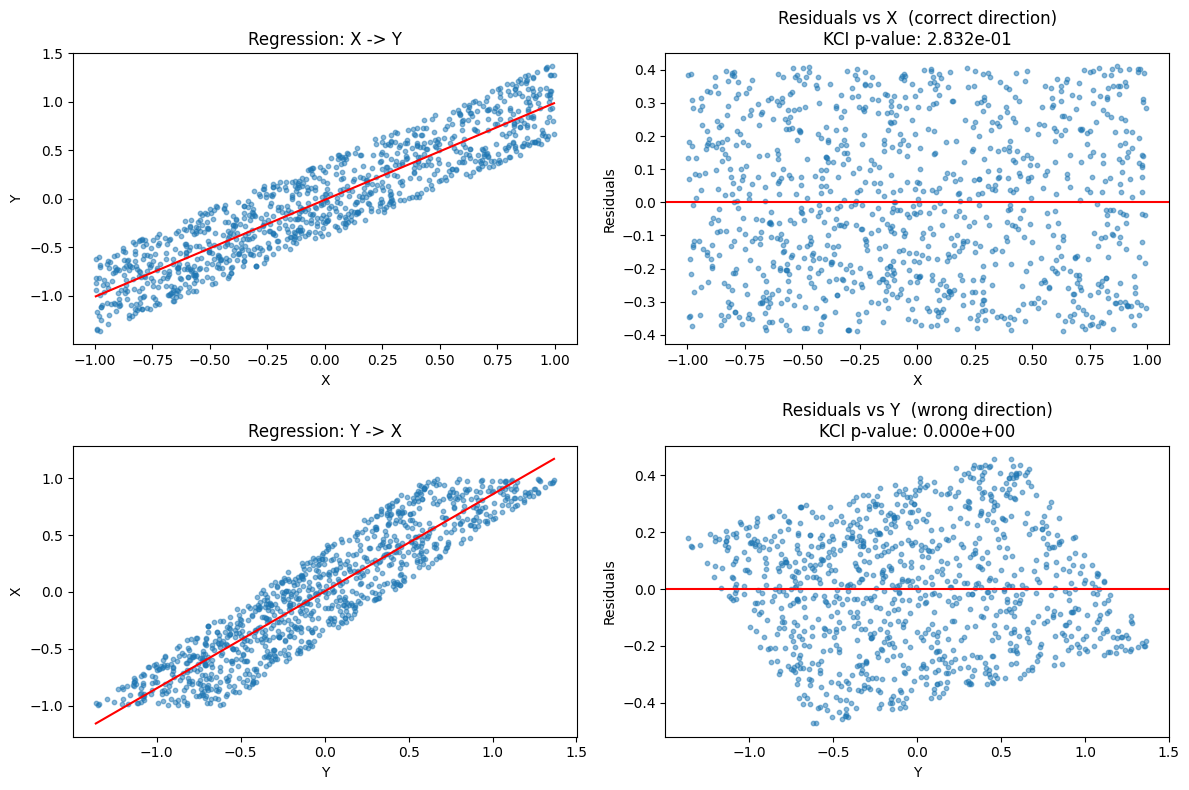


Correct direction (X -> Y): KCI p-value = 2.832e-01
Wrong direction  (Y -> X): KCI p-value = 0.000e+00

High p-value = fail to reject independence = direction is plausible
Low p-value  = dependence detected = direction is implausible


In [ ]:
# Generate data from X -> Y with uniform noise
scm = SCMGenerator(d=1)
scm.fit(
    n_parents=1,
    n_childs=0,
    n_spouses=0,
    sparsity=1,
    noise_type="uniform"
)

data = scm.sample(n_samples=1000)
X = data.X0.values.reshape(-1, 1)
Y = data.Y.values.reshape(-1, 1)

# Independence test object
kci = KCI_UInd()

# Regression: X -> Y
model_xy = LinearRegression().fit(X, Y)
y_pred = model_xy.predict(X)
res_xy = Y - y_pred

# Regression: Y -> X
model_yx = LinearRegression().fit(Y, X)
x_pred = model_yx.predict(Y)
res_yx = X - x_pred

# KCI independence tests
data = pd.DataFrame(np.hstack((X, Y, res_xy, res_yx)), columns=['X', 'Y', 'res_xy', 'res_yx'])
p_kci_xy = kci_test(data, 'X', 'res_xy')
p_kci_yx = kci_test(data, 'Y', 'res_yx')

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(X, Y, alpha=0.5, s=10)
axes[0, 0].plot(np.sort(X, axis=0), model_xy.predict(np.sort(X, axis=0)), color='red')
axes[0, 0].set_title("Regression: X -> Y")
axes[0, 0].set_xlabel("X"); axes[0, 0].set_ylabel("Y")

axes[0, 1].scatter(X, res_xy, alpha=0.5, s=10)
axes[0, 1].axhline(0, color='red')
axes[0, 1].set_title(f"Residuals vs X  (correct direction)\nKCI p-value: {p_kci_xy:.3e}")
axes[0, 1].set_xlabel("X"); axes[0, 1].set_ylabel("Residuals")

axes[1, 0].scatter(Y, X, alpha=0.5, s=10)
axes[1, 0].plot(np.sort(Y, axis=0), model_yx.predict(np.sort(Y, axis=0)), color='red')
axes[1, 0].set_title("Regression: Y -> X")
axes[1, 0].set_xlabel("Y"); axes[1, 0].set_ylabel("X")

axes[1, 1].scatter(Y, res_yx, alpha=0.5, s=10)
axes[1, 1].axhline(0, color='red')
axes[1, 1].set_title(f"Residuals vs Y  (wrong direction)\nKCI p-value: {p_kci_yx:.3e}")
axes[1, 1].set_xlabel("Y"); axes[1, 1].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

print(f"\nCorrect direction (X -> Y): KCI p-value = {p_kci_xy:.3e}")
print(f"Wrong direction  (Y -> X): KCI p-value = {p_kci_yx:.3e}")
print("\nHigh p-value = fail to reject independence = direction is plausible")
print("Low p-value  = dependence detected = direction is implausible")


### Questions — Pairwise RESIT (synthetic)

**Q1.** Why does RESIT work for non-Gaussian noise but fail for Gaussian noise? What breaks down in the linear Gaussian case?

**Q2.** In the residual plots above: what shape would you expect in the wrong-direction residuals if Y = X² + ε?

**Q3.** We used a linear regression model. What are the risks of using a model that is too flexible (e.g., a polynomial of very high degree)? And too simple?


**Answers:**

**A1.** In the linear Gaussian case, if Y = aX + ε with ε ~ N(0,σ²), then the residuals from Y→X regression *also* satisfy X ⊥ residuals. This is because the bivariate Gaussian distribution is symmetric with respect to regression: the residuals from regressing X on Y are also independent of Y. The non-Gaussian noise breaks this symmetry — the ANM (Additive Noise Model) is identifiable if and only if the noise is non-Gaussian (or the function is nonlinear). See Hoyer et al. (2009).

**A2.** If Y = X² + ε, regressing X on Y (wrong direction) gives a linear fit to a U-shaped relationship. The residuals would show a curved pattern — large positive values for intermediate Y, pulled down for extreme Y — clearly dependent on Y. The KCI test would flag this.

**A3.** Too flexible: overfitting means the residuals absorb the signal, artificially making them "independent" of X in both directions — RESIT becomes unreliable. Too simple: underfitting in the wrong direction may leave structured residuals that the test might still miss, reducing power. The model should be expressive enough to fit the true f, but not so much that it fits noise.


### 1.4 Real data — Tübingen cause-effect pairs

The Tübingen dataset is a benchmark of ~100 real-world cause-effect pairs (altitude/temperature, age/height, etc.), with ground-truth causal direction labels.

We now use a Gaussian Process (GP) regression instead of linear regression, to handle nonlinear relationships.


Ground truth direction: 1.0
Number of samples: 349


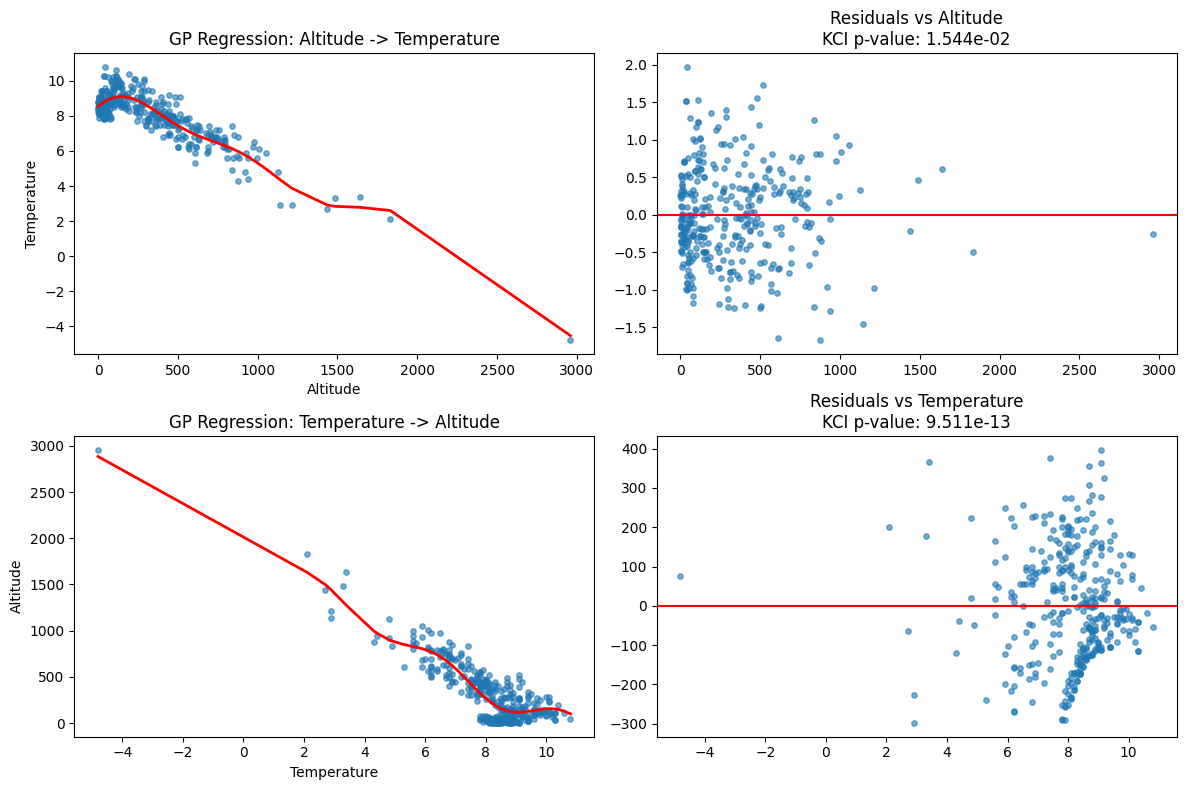


Altitude -> Temperature: KCI p-value = 1.544e-02
Temperature -> Altitude: KCI p-value = 9.511e-13

Predicted direction: Altitude -> Temperature


In [ ]:
# Load Tübingen dataset
data_tueb, labels = load_dataset("tuebingen")

# Altitude -> Temperature pair (pair 0)
pair_id = 0
X = data_tueb.iloc[pair_id]['A'].reshape(-1, 1)
Y = data_tueb.iloc[pair_id]['B'].reshape(-1, 1)

print("Ground truth direction:", labels.iloc[pair_id].values[0])
print(f"Number of samples: {len(X)}")

# GP regression
kernel = C(1.0) * RBF(length_scale=1.0)
gp_xy = GaussianProcessRegressor(kernel=kernel, alpha=4e-1, normalize_y=True)
gp_yx = GaussianProcessRegressor(kernel=kernel, alpha=4e-1, normalize_y=True)

kci = KCI_UInd()

# X -> Y
gp_xy.fit(X, Y)
y_pred = gp_xy.predict(X)
res_xy = Y.flatten() - y_pred
data = pd.DataFrame(np.hstack((X, res_xy[:, None])), columns=['X', 'res_xy'])

p_kci_xy = kci_test(data, 'X', 'res_xy')

# Y -> X
gp_yx.fit(Y, X)
x_pred = gp_yx.predict(Y)
res_yx = X.flatten() - x_pred
data = pd.DataFrame(np.hstack((Y, res_yx[:, None])), columns=['Y', 'res_yx'])
p_kci_yx = kci_test(data, 'Y', 'res_yx')

# Plot
idx_x = np.argsort(X.flatten())
idx_y = np.argsort(Y.flatten())

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(X, Y, alpha=0.6, s=15)
axes[0, 0].plot(X[idx_x], y_pred[idx_x], color="red", linewidth=2)
axes[0, 0].set_title("GP Regression: Altitude -> Temperature")
axes[0, 0].set_xlabel("Altitude"); axes[0, 0].set_ylabel("Temperature")

axes[0, 1].scatter(X, res_xy, alpha=0.6, s=15)
axes[0, 1].axhline(0, color="red")
axes[0, 1].set_title(f"Residuals vs Altitude\nKCI p-value: {p_kci_xy:.3e}")

axes[1, 0].scatter(Y, X, alpha=0.6, s=15)
axes[1, 0].plot(Y[idx_y], x_pred[idx_y], color="red", linewidth=2)
axes[1, 0].set_title("GP Regression: Temperature -> Altitude")
axes[1, 0].set_xlabel("Temperature"); axes[1, 0].set_ylabel("Altitude")

axes[1, 1].scatter(Y, res_yx, alpha=0.6, s=15)
axes[1, 1].axhline(0, color="red")
axes[1, 1].set_title(f"Residuals vs Temperature\nKCI p-value: {p_kci_yx:.3e}")

plt.tight_layout()
plt.show()

print(f"\nAltitude -> Temperature: KCI p-value = {p_kci_xy:.3e}")
print(f"Temperature -> Altitude: KCI p-value = {p_kci_yx:.3e}")
predicted = "Altitude -> Temperature" if p_kci_xy > p_kci_yx else "Temperature -> Altitude"
print(f"\nPredicted direction: {predicted}")


### Exercise 1 — Try another pair

The Tübingen dataset has many pairs. Try `pair_id = 3` (age vs. height of children) or pick one of your choice.

- Load the pair
- Run RESIT with both linear and GP regression
- Compare results and comment on whether the discovered direction matches your physical intuition


In [ ]:
# Your code here
# pair_id = 3
# X = data_tueb.iloc[pair_id]['A'].reshape(-1, 1)
# Y = data_tueb.iloc[pair_id]['B'].reshape(-1, 1)
# ...


### Questions — GP and real data

**Q4.** Why do we use a GP instead of linear regression on the Tübingen data?

**Q5.** The KCI test has a significance threshold α. What happens to RESIT's decision if you set α very small (say 1e-10)? What if α = 0.5?

**Q6.** RESIT assumes an additive noise model: Y = f(X) + ε. Name a real-world situation where this assumption is violated and discuss what would happen to the test.


**Answers:**

**A4.** Real-world relationships (altitude/temperature, age/height) are typically nonlinear. A linear model would leave structured residuals even in the correct direction, making the KCI test falsely detect dependence. The GP is flexible enough to fit the true nonlinear relationship, so that residuals in the correct direction are genuinely noise-like.

**A5.** Very small α: RESIT becomes very conservative — it fails to reject independence in both directions (treating both as plausible), and cannot make a decision. α = 0.5: RESIT becomes too lenient — even dependent residuals might not be flagged. The decision becomes unreliable in both directions. In practice, α = 0.05 is standard, but tuning may be needed.

**A6.** Multiplicative noise: Y = f(X) · ε violates the additive structure. For instance, stock returns might be better modeled this way. In this case, the residuals from a standard regression include the interaction between f(X) and ε — which won't be independent of X even in the correct direction. RESIT would fail to identify either direction reliably.


## SHOULD I INVERT SECTION 1 AND 1.5: FIRST LIMITS OF MEC AND SHOWING POSSIBLE OPTIONS